# 05. Incertidumbre de estimación

En el notebook 04 vimos que los pesos óptimos cambian mucho según el periodo usado para estimar. Aquí cuantifico por qué:

1. **Error de estimación de las medias:** cuánto se equivoca, como mínimo, una rentabilidad media estimada con 10 años de datos.
2. **Bootstrap de los pesos:** remuestreo los datos muchas veces y miro cuánto cambia la cartera de máximo Sharpe.


In [17]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.portfolio import (error_estandar_medias, error_estandar_sharpe,
                               bootstrap_pesos_max_sharpe, resumen_pesos)

precios = pd.read_csv("../data/precios.csv", index_col="Date", parse_dates=True)
rentabilidades = precios.pct_change().dropna()
rf_hist = pd.read_csv("../data/rf_hist.csv", index_col=0).squeeze("columns")["rf_hist"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Error de estimación de la rentabilidad media

Una rentabilidad media estimada con pocos años de datos es muy imprecisa. El error estándar de la media es aproximadamente la volatilidad anual dividida por la raíz de los años de datos. El intervalo del 95 % es la media ± 2 errores estándar.

In [18]:
print(f"Error estándar aproximado del Sharpe de cada activo: {error_estandar_sharpe(rentabilidades):.2f}")
error_estandar_medias(rentabilidades).round(3)

Error estándar aproximado del Sharpe de cada activo: 0.32


,Rentabilidad anual,Volatilidad anual,Error estándar,IC 95% inferior,IC 95% superior
AGG,0.021,0.054,0.017,-0.013,0.055
EEM,0.099,0.203,0.064,-0.030,0.228
EFA,0.096,0.172,0.055,-0.013,0.205
GLD,0.146,0.148,0.047,0.052,0.240
SPY,0.155,0.180,0.057,0.041,0.269
VNQ,0.073,0.208,0.066,-0.058,0.205


Bootstrap de los pesos óptimos

Remuestreo los datos 200 veces, pegando bloques de 21 días elegidos al azar (así se conserva la dependencia entre días consecutivos), y en cada remuestreo recalculo la cartera de máximo Sharpe. Si los pesos cambian mucho de un remuestreo a otro, la "cartera óptima" es en realidad un rango.

Este bootstrap solo mide el **error de muestreo**: remuestrea los mismos diez años. No captura un cambio de régimen como el de los tipos de interés.

In [19]:
pesos_boot = bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=200)
resumen_pesos(pesos_boot).round(3)

,Peso medio,Percentil 5,Percentil 95
AGG,0.018,0.000,0.165
EEM,0.003,0.000,0.000
EFA,0.001,0.000,0.000
GLD,0.549,0.303,0.796
SPY,0.425,0.197,0.669
VNQ,0.004,0.000,0.000


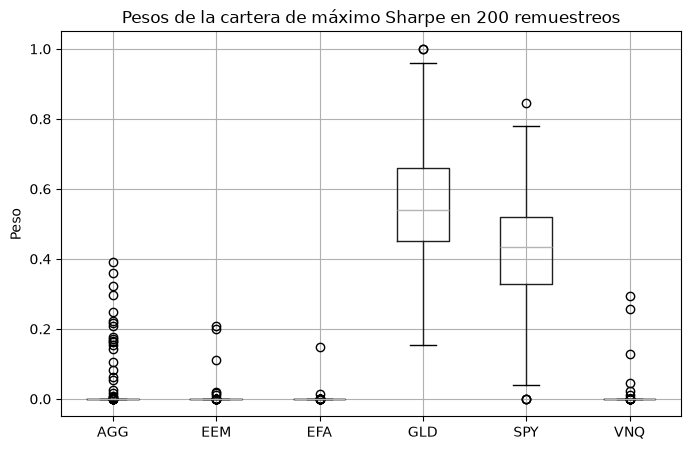

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
pesos_boot.boxplot(ax=ax)
ax.set_title("Pesos de la cartera de máximo Sharpe en 200 remuestreos")
ax.set_ylabel("Peso")
plt.show()